# Painel da Atenção Primária: seis programas, um município

**Pergunta que este notebook responde:** como o meu município está nos
programas da atenção primária — equipes multiprofissionais, saúde bucal,
Academia da Saúde, Farmácia Popular, telessaúde e especialidades odontológicas
— comparado com a sua região de saúde, o estado e o Brasil?

**Fonte:** indicadores MGDI do Ministério da Saúde, publicados como CSV no
portal de dados abertos. São **89 indicadores de atenção primária** que
compartilham o **mesmo formato de 25 colunas** — a receita deste notebook serve
para qualquer um deles.
**Tempo estimado:** 4 a 8 minutos.

> Estes dados não vêm do FTP do DATASUS nem da PySUS: são arquivos `.csv.zip`
> publicados direto em armazenamento público. É a fonte mais estável da
> atenção primária — enquanto a API do Ministério ficava fora do ar, estes
> arquivos continuavam respondendo.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

Escreva o **nome** do município e a sigla do estado. O código do IBGE é
descoberto a partir dos próprios dados — digitar código de cabeça é uma das
formas mais fáceis de analisar o município errado sem perceber.

In [3]:
MUNICIPIO = "Londrina"
UF = "PR"

## Passo 1 — Seis indicadores, uma receita só

Cada indicador é um arquivo `.csv.zip` com as mesmas 25 colunas: o valor do
município, o da região de saúde, o do estado, o do Brasil, e a identificação
geográfica completa. Trocar o indicador é trocar o nome do arquivo.

In [4]:
import io
import zipfile
import httpx
import pandas as pd

BASE = "https://demas-dados-abertos.s3.amazonaws.com/csv/"
VALOR = "vl_indicador_calculado_mun"

INDICADORES = {
    "emultcust":   "Equipes multiprofissionais (eMulti)",
    "sbesb40h":    "Equipes de Saúde Bucal 40h",
    "pasnpcust":   "Polos do Academia da Saúde",
    "pfpbben":     "Atendidos pela Farmácia Popular",
    "mgdi_ms_3pn": "Teleconsultorias na APS",
    "ceoimp":      "Centros de Especialidades Odontológicas",
}

def baixar_indicador(chave):
    with httpx.Client(timeout=300, follow_redirects=True) as cliente:
        resposta = cliente.get(f"{BASE}{chave}.csv.zip")
    resposta.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resposta.content)) as arquivo:
        interno = arquivo.namelist()[0]
        return pd.read_csv(io.BytesIO(arquivo.read(interno)), low_memory=False)

tabelas = {}
for chave, rotulo in INDICADORES.items():
    tabelas[chave] = baixar_indicador(chave)
    print(f"{rotulo:42s} {len(tabelas[chave]):>8,} linhas")

print(f"\nTodos com as mesmas {len(tabelas['sbesb40h'].columns)} colunas: "
      f"{tabelas['sbesb40h'].columns.equals(tabelas['ceoimp'].columns)}")

Equipes multiprofissionais (eMulti)         155,988 linhas


Equipes de Saúde Bucal 40h                   61,273 linhas


Polos do Academia da Saúde                   38,993 linhas


Atendidos pela Farmácia Popular              61,273 linhas


Teleconsultorias na APS                      11,142 linhas


Centros de Especialidades Odontológicas      61,273 linhas
Todos com as mesmas 25 colunas: True


## Passo 2 — A armadilha da periodicidade

`co_anomes` está no formato AAAAMM e parece uma série mensal. Não é — e **não é
igual para todos os indicadores**. Uns são mensais, outros trazem dezembro de
cada ano, outros junho. Comparar "o dado mais recente" de cada um significa
comparar retratos tirados em datas diferentes.

In [5]:
calendario = []
for chave, rotulo in INDICADORES.items():
    competencias = sorted(tabelas[chave]["co_anomes"].unique())
    meses = sorted({str(c)[4:] for c in competencias})
    calendario.append({
        "indicador": rotulo,
        "competências": len(competencias),
        "da": min(competencias),
        "até": max(competencias),
        "meses publicados": ", ".join(meses) if len(meses) <= 4 else "mensal",
    })
pd.DataFrame(calendario)

,indicador,competências,da,até,meses publicados
0,Equipes multiprofissionais (eMulti),28,202405,202608,mensal
1,Equipes de Saúde Bucal 40h,11,201612,202608,"08, 12"
2,Polos do Academia da Saúde,7,202012,202606,"06, 12"
3,Atendidos pela Farmácia Popular,11,201612,202607,"07, 12"
4,Teleconsultorias na APS,2,202512,202604,"04, 12"
5,Centros de Especialidades Odontológicas,11,201612,202606,"06, 12"


In [6]:
conjuntos = [set(t["co_anomes"]) for t in tabelas.values()]
comuns = sorted(set.intersection(*conjuntos))
COMPETENCIA = max(comuns)

print(f"Competências comuns aos seis indicadores: {comuns}")
print(f"\nUsaremos {COMPETENCIA} — a única data em que os seis existem ao mesmo tempo.")
print("Comparar o 'mais recente' de cada um seria comparar meses diferentes.")

Competências comuns aos seis indicadores: [202512]
Usaremos 202512 — a única data em que os seis existem ao mesmo tempo.
Comparar o 'mais recente' de cada um seria comparar meses diferentes.


## Passo 3 — Achar o município sem digitar código

O nome vem com acentuação e caixa variáveis entre bases. Procuramos pelo nome
dentro da UF escolhida e conferimos o que foi encontrado antes de seguir.

In [7]:
referencia = tabelas["sbesb40h"]
candidatos = referencia[
    (referencia["sg_uf"] == UF)
    & (referencia["no_municipio"].str.lower() == MUNICIPIO.lower())
]

if candidatos.empty:
    parecidos = referencia[
        (referencia["sg_uf"] == UF)
        & referencia["no_municipio"].str.contains(MUNICIPIO, case=False, na=False)
    ]["no_municipio"].unique()
    raise SystemExit(f"Não encontrei '{MUNICIPIO}' em {UF}. Parecidos: {parecidos[:10]}")

CODIGO = int(candidatos["co_ibge"].iloc[0])
linha = candidatos.iloc[0]
print(f"Município: {linha['no_municipio']} ({UF}) — código IBGE {CODIGO}")
print(f"Região de saúde: {linha['no_regiao_saude']}")
print(f"Macrorregião:    {linha['no_macro']}")

Município: Londrina (PR) — código IBGE 411370
Região de saúde: 17ª RS Londrina
Macrorregião:    Macrorregional Norte


## Passo 4 — O painel

As colunas `vl_indicador_calculado_*` já trazem o valor agregado em cada nível
— região de saúde, macrorregião, UF, região do país e Brasil. Vale conferir se
elas fecham com a soma dos municípios, e o resultado guarda uma surpresa.

In [8]:
painel = []
for chave, rotulo in INDICADORES.items():
    recorte = tabelas[chave]
    recorte = recorte[recorte["co_anomes"] == COMPETENCIA]
    alvo = recorte[recorte["co_ibge"] == CODIGO]
    if alvo.empty:
        continue
    r = alvo.iloc[0]
    painel.append({
        "indicador": rotulo,
        "município": r[VALOR],
        "região de saúde": r["vl_indicador_calculado_rs"],
        "estado": r["vl_indicador_calculado_uf"],
        "Brasil": r["vl_indicador_calculado_br"],
    })

painel = pd.DataFrame(painel).set_index("indicador")
print(f"{linha['no_municipio']} — competência {COMPETENCIA}\n")
painel

Londrina — competência 202512


,município,região de saúde,estado,Brasil
indicador,,,,
Equipes multiprofissionais (eMulti),7.0,20.0,271.0,6291
Equipes de Saúde Bucal 40h,21.0,90.0,1269.0,32938
Polos do Academia da Saúde,0.0,0.0,75.0,1559
Atendidos pela Farmácia Popular,33383.0,84168.0,883538.0,11942618
Teleconsultorias na APS,0.0,0.0,10477.0,15257
Centros de Especialidades Odontológicas,2.0,5.0,51.0,1186


In [9]:
# as colunas agregadas fecham com a soma dos municípios?
conferencia = []
for chave, rotulo in INDICADORES.items():
    recorte = tabelas[chave]
    recorte = recorte[recorte["co_anomes"] == COMPETENCIA]
    conferencia.append({
        "indicador": rotulo,
        "soma dos municípios": recorte[VALOR].sum(),
        "Brasil declarado": recorte["vl_indicador_calculado_br"].iloc[0],
    })
conferencia = pd.DataFrame(conferencia)
conferencia["confere"] = (conferencia["soma dos municípios"]
                          == conferencia["Brasil declarado"])
conferencia["diferença"] = (conferencia["soma dos municípios"]
                            - conferencia["Brasil declarado"])
conferencia

,indicador,soma dos municípios,Brasil declarado,confere,diferença
0,Equipes multiprofissionais (eMulti),6291.0,6291,True,0.0
1,Equipes de Saúde Bucal 40h,32938.0,32938,True,0.0
2,Polos do Academia da Saúde,1559.0,1559,True,0.0
3,Atendidos pela Farmácia Popular,12008228.0,11942618,False,65610.0
4,Teleconsultorias na APS,15257.0,15257,True,0.0
5,Centros de Especialidades Odontológicas,1186.0,1186,True,0.0


Cinco fecham na casa da unidade. **Um não fecha** — e não é erro do arquivo.

Repare no que cada indicador conta. Equipes, polos e centros são *coisas*, e
cada uma pertence a um município só: somar dá o total do país. A Farmácia
Popular conta **pessoas atendidas**, e a mesma pessoa pode ser atendida em mais
de um município — some por município e ela entra duas vezes; o total nacional a
conta uma vez.

A regra que sai daqui: **antes de somar, pergunte o que a unidade de medida
é.** Quando o indicador conta pessoas, use a coluna agregada que o próprio
arquivo traz, nunca a soma dos municípios.

## Passo 5 — Sem denominador, o painel engana

Um município com 30 equipes não está necessariamente melhor que outro com 5:
depende de quantas pessoas cada um atende. Os arquivos do MGDI **não trazem
população** — o denominador vem do IBGE, pela PySUS.

Atenção ao código do município: o IBGE usa **7 dígitos** (com dígito
verificador) e o MGDI usa **6**. Juntar sem cortar não casa nada.

In [10]:
import pysus

arquivos_ibge = pysus.ibge(year=2024)
arquivo_populacao = [p for p in arquivos_ibge if "POPTBR" in str(p)]
populacao = pd.read_parquet(arquivo_populacao[0])
populacao["POPULACAO"] = pd.to_numeric(populacao["POPULACAO"], errors="coerce")

por_municipio = (populacao.groupby("MUNIC_RES", as_index=False)["POPULACAO"].sum())
por_municipio["co_ibge"] = por_municipio["MUNIC_RES"].astype(str).str[:6].astype(int)

print(f"IBGE:  {por_municipio['MUNIC_RES'].iloc[0]} (7 dígitos)")
print(f"MGDI:  {CODIGO} (6 dígitos)")
print(f"\n{len(por_municipio):,} municípios com população; "
      f"total {por_municipio['POPULACAO'].sum():,.0f} habitantes")

IBGE:  1100015 (7 dígitos)
MGDI:  411370 (6 dígitos)
5,570 municípios com população; total 212,583,750 habitantes


In [11]:
saude_bucal = tabelas["sbesb40h"]
saude_bucal = saude_bucal[saude_bucal["co_anomes"] == COMPETENCIA]

com_populacao = saude_bucal.merge(por_municipio[["co_ibge", "POPULACAO"]],
                                  on="co_ibge", how="left")
sem_par = com_populacao[com_populacao["POPULACAO"].isna()]
print(f"Municípios sem população no arquivo do IBGE: {len(sem_par)}")
if len(sem_par):
    print(sem_par[["co_ibge", "no_municipio", "sg_uf"]].to_string(index=False))
    print("\n(municípios criados depois da referência do arquivo de população — "
          "some do denominador sem avisar)")

com_populacao["por_100mil"] = (100000 * com_populacao[VALOR]
                               / com_populacao["POPULACAO"])
brasil = 100000 * com_populacao[VALOR].sum() / com_populacao["POPULACAO"].sum()
meu = com_populacao.loc[com_populacao["co_ibge"] == CODIGO, "por_100mil"].iloc[0]
print(f"\nEquipes de Saúde Bucal 40h por 100 mil habitantes:")
print(f"  {linha['no_municipio']}: {meu:.1f}")
print(f"  Brasil:      {brasil:.1f}")

Municípios sem população no arquivo do IBGE: 1
 co_ibge           no_municipio sg_uf
  510183 Boa Esperança do Norte    MT
(municípios criados depois da referência do arquivo de população — some do denominador sem avisar)
Equipes de Saúde Bucal 40h por 100 mil habitantes:
  Londrina: 3.6
  Brasil:      15.5


## Passo 6 — Zero não quer dizer ausência

Este é o erro mais fácil de cometer com esta base. Cada indicador mede **uma
modalidade**, não o serviço inteiro. Um município pode aparecer com zero
equipes de saúde bucal de 40 horas e ter equipes com carga horária
diferenciada, que são contadas em outro arquivo.

In [12]:
quarenta = tabelas["sbesb40h"]
quarenta = quarenta[quarenta["co_anomes"] == COMPETENCIA][["co_ibge", VALOR]]
quarenta = quarenta.rename(columns={VALOR: "somente_40h"})

completo = baixar_indicador("sbesb")     # 40h + carga horária diferenciada
completo = completo[completo["co_anomes"] == COMPETENCIA][["co_ibge", VALOR]]
completo = completo.rename(columns={VALOR: "todas_modalidades"})

comparado = quarenta.merge(completo, on="co_ibge")
zerados = comparado[comparado["somente_40h"] == 0]
enganosos = (zerados["todas_modalidades"] > 0).sum()

print(f"Municípios com ZERO no indicador de 40h: {len(zerados):,}")
print(f"Destes, com equipe em outra modalidade:  {enganosos:,} "
      f"({enganosos / len(zerados) * 100:.0f}%)")
print(f"\nNo Brasil: {comparado['somente_40h'].sum():,.0f} equipes de 40h, "
      f"mas {comparado['todas_modalidades'].sum():,.0f} no total.")
print("Ler o zero como 'não tem saúde bucal' erra em um a cada três casos.")

Municípios com ZERO no indicador de 40h: 502
Destes, com equipe em outra modalidade:  147 (29%)
No Brasil: 32,938 equipes de 40h, mas 34,936 no total.
Ler o zero como 'não tem saúde bucal' erra em um a cada três casos.


## Passo 7 — A coluna que ninguém documenta: Amazônia Legal

O arquivo tem uma coluna `vl_indicador_calculado_al` cujo nome não diz o que
ela é. Ela vale zero na maioria das linhas e, nas demais, sempre o mesmo
número. Descobrimos o que é testando: são exatamente **773 municípios das nove
UFs da Amazônia Legal**, e o valor é o total do recorte.

In [13]:
UFS_AMAZONIA_LEGAL = {"AC", "AM", "AP", "MA", "MT", "PA", "RO", "RR", "TO"}

marcados = saude_bucal[saude_bucal["vl_indicador_calculado_al"] != 0]
soma = marcados[VALOR].sum()
declarado = marcados["vl_indicador_calculado_al"].iloc[0]

print(f"Municípios com a coluna preenchida: {marcados['co_ibge'].nunique()}")
print(f"UFs desses municípios: {sorted(marcados['sg_uf'].unique())}")
print(f"São todas da Amazônia Legal? "
      f"{set(marcados['sg_uf'].unique()) <= UFS_AMAZONIA_LEGAL}")
print(f"\nSoma do indicador nesses municípios: {soma:,.0f}")
print(f"Valor declarado na coluna:           {declarado:,.0f}")
print(f"Confere: {soma == declarado}")
print(f"\nA Amazônia Legal concentra "
      f"{100 * soma / saude_bucal['vl_indicador_calculado_br'].iloc[0]:.1f}% "
      f"das equipes do país.")

Municípios com a coluna preenchida: 773
UFs desses municípios: ['AC', 'AM', 'AP', 'MA', 'MT', 'PA', 'RO', 'RR', 'TO']
São todas da Amazônia Legal? True
Soma do indicador nesses municípios: 5,168
Valor declarado na coluna:           5,168
Confere: True
A Amazônia Legal concentra 15.7% das equipes do país.


## Passo 8 — A posição do município na sua região de saúde

A comparação que o gestor municipal mais usa: como estou perto dos meus
vizinhos, que enfrentam a mesma realidade e dividem a mesma referência.

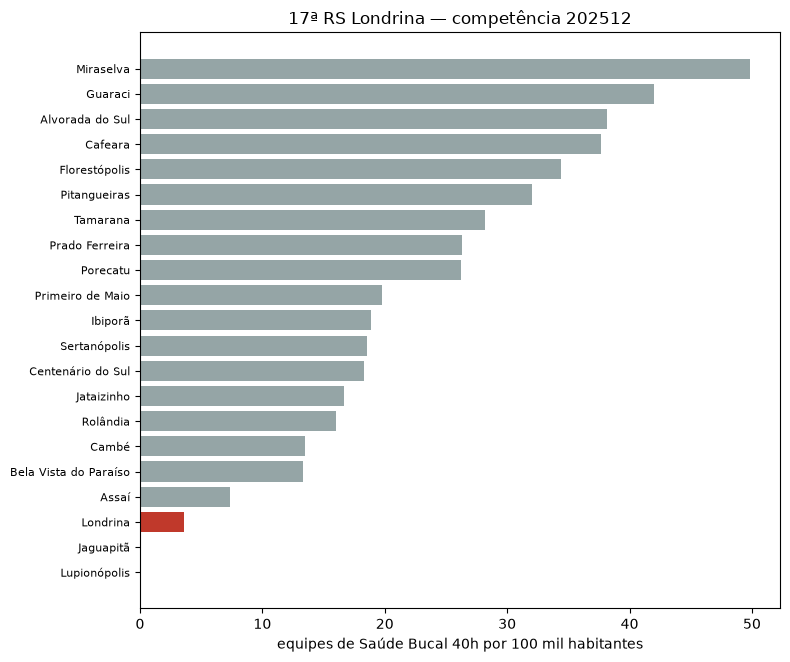

Londrina é o 19º de 21 municípios da região, por 100 mil habitantes.
Quantos empatam em zero: 2


In [14]:
import matplotlib.pyplot as plt

regiao = int(linha["co_regiao_saude"])
vizinhos = com_populacao[com_populacao["co_regiao_saude"] == regiao].copy()
vizinhos = vizinhos.dropna(subset=["por_100mil"]).sort_values("por_100mil")

cores = ["#c0392b" if c == CODIGO else "#95a5a6" for c in vizinhos["co_ibge"]]

fig, ax = plt.subplots(figsize=(8, max(3, 0.32 * len(vizinhos))))
ax.barh(vizinhos["no_municipio"], vizinhos["por_100mil"], color=cores)
ax.set_xlabel("equipes de Saúde Bucal 40h por 100 mil habitantes")
ax.set_title(f"{linha['no_regiao_saude']} — competência {COMPETENCIA}")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

posicao = list(vizinhos.sort_values("por_100mil", ascending=False)["co_ibge"]).index(CODIGO) + 1
print(f"{linha['no_municipio']} é o {posicao}º de {len(vizinhos)} "
      f"municípios da região, por 100 mil habitantes.")
print(f"Quantos empatam em zero: {(vizinhos['por_100mil'] == 0).sum()}")

## O que este notebook não responde

- **Zero é modalidade, não serviço.** O passo 6 mede o preço do erro: um em
  cada três "zeros" tem equipe em outra modalidade.
- **Cada indicador tem o seu calendário.** Os seis só coincidem numa
  competência. Se você trocar os indicadores, refaça o passo 2.
- **O denominador envelhece.** Municípios criados depois da referência do
  arquivo de população somem da conta — o passo 5 mostra quais.
- **Contar equipe não é medir acesso.** Uma equipe custeada não garante
  atendimento prestado. Para desempenho, veja o notebook do Previne Brasil.
- **Nem todo indicador é somável.** Os que contam pessoas não fecham por
  município — o passo 4 mostra a diferença e explica por quê.
- **São 89 indicadores de APS neste formato.** Este notebook usa seis; trocar o
  nome do arquivo no passo 1 traz qualquer outro.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [ ]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

conferir(1, "O painel tem indicadores", len(painel) > 0, f"{len(painel)} linhas")
# 'painel' tem os indicadores no INDICE e os valores nas colunas: o nome do
# municipio nao esta nos valores. Quem guarda o municipio escolhido e 'linha'.
conferir(2, "A linha do município escolhido foi encontrada",
         str(linha.get("co_ibge", "")).startswith(str(CODIGO)[:6]),
         f"{MUNICIPIO} (IBGE {linha.get('co_ibge', '?')})")
conferir(3, "Nenhum indicador ficou vazio",
         not painel.isna().all(axis=1).any())
conferir(4, "População do município é plausível",
         float(linha["POPULACAO"]) > 1000 if "POPULACAO" in linha else True,
         f"{float(linha['POPULACAO']):,.0f} habitantes" if "POPULACAO" in linha else "")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")